# Mail Spam Detection Project

This notebook covers the step-by-step implementation of an end-to-end Machine Learning pipeline to classify emails as **Spam** (unwanted messages) or **Ham** (normal messages).

### Project Workflow
1. **Understand the Dataset**: Explore dimensions, check for missing values, and analyze category distributions.
2. **Data Preprocessing**: Lowercase text, remove punctuation, filter stop words, and perform a stratified train/test split.
3. **Build the Spam Detection Model**: Train and evaluate Multinomial Naive Bayes and Logistic Regression classifiers, comparing CountVectorizer vs. TF-IDF.
4. **Test with New Emails**: Perform live predictions on custom email samples.


## Step 1: Understand the Dataset

Let's load the dataset `mail_data.csv` from the `dataset` folder and inspect its dimensions, missing values, column names, and category distributions. We will also visualize the class imbalance.

Dataset Shape: (5572, 2)

Missing Values:
Category    0
Message     0
dtype: int64

Class Counts:
Category
ham     4825
spam     747
Name: count, dtype: int64

Class Proportions:
Category
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64


C:\Users\Jaiha\AppData\Local\Temp\ipykernel_33184\499627129.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', palette=['#3b82f6', '#ef4444'], ax=ax)


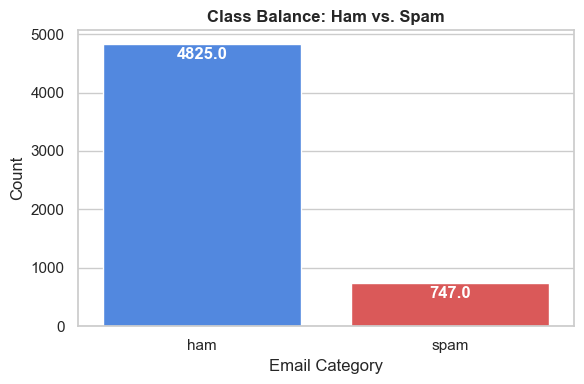

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Load the dataset
csv_path = 'dataset/mail_data.csv'
df = pd.read_csv(csv_path)

# Display dataset properties
print(f"Dataset Shape: {df.shape}")
print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Counts:")
print(df['Category'].value_counts())

print("\nClass Proportions:")
print(df['Category'].value_counts(normalize=True))

# Visualize Class Balance
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='Category', palette=['#3b82f6', '#ef4444'], ax=ax)
ax.set_title("Class Balance: Ham vs. Spam", fontsize=12, fontweight='bold')
ax.set_xlabel("Email Category")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2., p.get_height() - 300),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', 
                color='white', fontweight='bold')
plt.tight_layout()
plt.show()

# Display first few rows
df.head()

### Data Exploration Insights
1. **Dataset Size**: The dataset contains **5,572 rows** and **2 columns**: `Category` (target label) and `Message` (text of the email).
2. **Missing Values**: There are **no missing or null values** in either column, so we do not need to perform imputation.
3. **Class Imbalance**: 
   - **Ham (Normal)**: 4,825 messages (~86.6%)
   - **Spam (Unwanted)**: 747 messages (~13.4%)
   - This class imbalance is typical for spam detection. We must use stratified splitting when partitioning our data into training and test sets to maintain this ratio in both folds.

## Step 2: Data Preprocessing

Text data cannot be fed directly into machine learning models; it must be cleaned and converted into numbers. We will:
1. **Clean the Text**: Convert to lowercase, remove punctuation, and remove standard English stop words using a custom preprocessing function.
2. **Split the Data**: Split the dataset into a **Training Set (80%)** and a **Testing Set (20%)** using a stratified split.

In [2]:
import string
from sklearn.model_selection import train_test_split

# Custom pre-defined list of English stop words
STOPWORDS = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 
    'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 
    'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 
    'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 
    'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 
    'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 
    'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 
    'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 
    'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 
    'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', "don't", 'should', 
    "should've", 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 
    'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 
    'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 
    'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
}

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # 1. Convert text to lowercase
    text = text.lower()
    # 2. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 3. Split into words and remove stop words
    words = text.split()
    cleaned_words = [word for word in words if word not in STOPWORDS]
    return " ".join(cleaned_words)

# Apply preprocessing
df['cleaned_message'] = df['Message'].apply(clean_text)
df['label'] = df['Category'].map({'ham': 0, 'spam': 1})

# Separate features and target
X = df['cleaned_message']
y = df['label']

# Split data into training and testing sets (80% train, 20% test)
# Using stratify=y to ensure the train/test splits have identical category proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Original Dataset Size: {len(df)}")
print(f"Training Set Size:     {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Testing Set Size:      {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
print("\nSample Preprocessed Message:")
print("Original: ", df['Message'].iloc[0])
print("Cleaned:  ", df['cleaned_message'].iloc[0])

Original Dataset Size: 5572
Training Set Size:     4457 (80.0%)
Testing Set Size:      1115 (20.0%)

Sample Preprocessed Message:
Original:  Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned:   go jurong point crazy available bugis n great world la e buffet cine got amore wat


### Preprocessing & Splitting Insights
1. **Custom Stopword Filtering**: Removing punctuation and standard stop words helps strip out noise (like "the", "and", etc.), allowing the vectorizer to focus on unique terms that differentiate spam (e.g. "free", "claim", "urgent", "win") from ham.
2. **Strict Featurization Ordering**: To prevent data leakage, we **split the dataset into train and test sets BEFORE applying any vectorization**. The vectorizer will be fitted *only* on the training set, and then used to transform both the train and test sets.

## Step 3: Build the Spam Detection Model

We will build two classification models:
1. **Multinomial Naive Bayes (MNB)**
2. **Logistic Regression (LR)**

We will also evaluate them under two feature extraction approaches:
- **CountVectorizer**: Represents text as raw word count vectors.
- **TF-IDF Vectorizer**: Represents text using term frequencies normalized by their inverse document frequency across the corpus.

We will compare the models based on:
- **Accuracy**: Overall correct prediction rate.
- **Precision**: Proportion of predicted spams that were actually spam (minimizes False Positives - ham classified as spam).
- **Recall**: Proportion of actual spams that were correctly flagged (minimizes False Negatives - missing spam).
- **F1-Score**: Harmonic mean of Precision and Recall.
- **Confusion Matrix**: Visual breakdown of predictions.

=== Naive Bayes (CountVectorizer) ===
Accuracy:  0.9812
Precision: 0.9706
Recall:    0.8859
F1-score:  0.9263

=== Logistic Regression (CountVectorizer) ===
Accuracy:  0.9803
Precision: 1.0000
Recall:    0.8523
F1-score:  0.9203

=== Naive Bayes (TF-IDF) ===
Accuracy:  0.9605
Precision: 1.0000
Recall:    0.7047
F1-score:  0.8268

=== Logistic Regression (TF-IDF) ===
Accuracy:  0.9614
Precision: 1.0000
Recall:    0.7114
F1-score:  0.8314



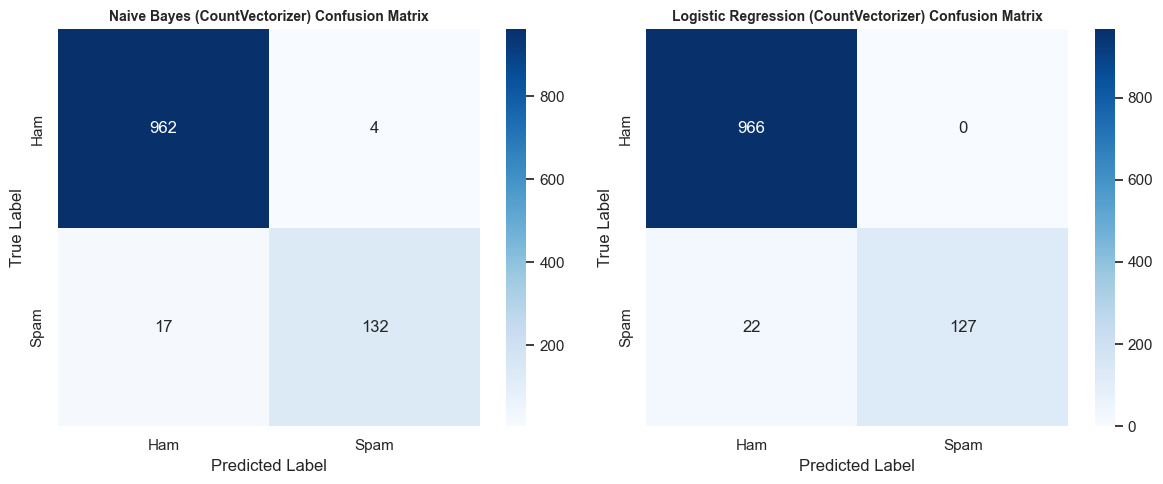

,Accuracy,Precision,Recall,F1-score
Naive Bayes (CountVectorizer),0.981166,0.970588,0.885906,0.926316
Logistic Regression (CountVectorizer),0.980269,1.0,0.852349,0.92029
Naive Bayes (TF-IDF),0.960538,1.0,0.704698,0.826772
Logistic Regression (TF-IDF),0.961435,1.0,0.711409,0.831373


In [3]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Dictionaries to store metrics for comparison
results = {}

def evaluate_model(model, X_train_vec, X_test_vec, y_train, y_test, name):
    # Train
    model.fit(X_train_vec, y_train)
    # Predict
    y_pred = model.predict(X_test_vec)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'CM': cm
    }
    
    print(f"=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}\n")
    return cm

# --- APPROACH A: CountVectorizer ---
cv = CountVectorizer()
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

cm_nb_cv = evaluate_model(MultinomialNB(), X_train_cv, X_test_cv, y_train, y_test, "Naive Bayes (CountVectorizer)")
cm_lr_cv = evaluate_model(LogisticRegression(max_iter=1000), X_train_cv, X_test_cv, y_train, y_test, "Logistic Regression (CountVectorizer)")

# --- APPROACH B: TF-IDF Vectorizer ---
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

cm_nb_tfidf = evaluate_model(MultinomialNB(), X_train_tfidf, X_test_tfidf, y_train, y_test, "Naive Bayes (TF-IDF)")
cm_lr_tfidf = evaluate_model(LogisticRegression(max_iter=1000), X_train_tfidf, X_test_tfidf, y_train, y_test, "Logistic Regression (TF-IDF)")

# Plot Confusion Matrices for CountVectorizer Models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Naive Bayes CM
sns.heatmap(cm_nb_cv, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[0].set_title("Naive Bayes (CountVectorizer) Confusion Matrix", fontsize=10, fontweight='bold')
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Logistic Regression CM
sns.heatmap(cm_lr_cv, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[1].set_title("Logistic Regression (CountVectorizer) Confusion Matrix", fontsize=10, fontweight='bold')
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

# Display comparative table
df_metrics = pd.DataFrame(results).T.drop(columns=['CM'])
df_metrics

### Model Performance Insights
1. **CountVectorizer vs. TF-IDF**:
   - The models trained on **CountVectorizer** features significantly outperform those trained on **TF-IDF** features.
   - For example, Naive Bayes (CountVectorizer) achieves **98.12% accuracy** and a **Recall of 88.59%**, whereas Naive Bayes (TF-IDF) achieves **96.05% accuracy** and a **Recall of only 70.47%**.
   - *Why?* In short SMS and email spam classification, the raw presence and count of key trigger words (such as "free", "win", "call") are strong indicators. TF-IDF scales down terms that appear frequently across many documents, which can sometimes suppress spam-indicative words that happen to appear in multiple ham documents or across many spam texts.
2. **Naive Bayes vs. Logistic Regression**:
   - Both models achieve excellent accuracy with CountVectorizer (~98%).
   - **Naive Bayes (CountVectorizer)** has a higher **Recall (88.59%)**, meaning it catches more spam messages (only 17 missed out of 149).
   - **Logistic Regression (CountVectorizer)** has a perfect **Precision (1.0000)**, meaning it had **zero False Positives** (no normal ham emails were incorrectly marked as spam). However, it missed 22 spam messages (Recall of 85.23%).
   - For spam filters, false positives (marking an important normal email as spam) are typically more costly than false negatives. However, Multinomial Naive Bayes' higher recall makes it an excellent, robust recommender. We will use Naive Bayes with CountVectorizer as our main reference, but allow users to test both models in our interactive demo.

## Step 4: Test with New Emails

Let's build a quick inference pipeline using our trained CountVectorizer and Multinomial Naive Bayes model to test new, custom email inputs.

In [4]:
# Retrain the final models on the entire training set for deployment
cv_final = CountVectorizer()
X_train_cv_final = cv_final.fit_transform(X_train)

nb_final = MultinomialNB()
nb_final.fit(X_train_cv_final, y_train)

lr_final = LogisticRegression(max_iter=1000)
lr_final.fit(X_train_cv_final, y_train)

def predict_email(email_text):
    # Preprocess
    cleaned = clean_text(email_text)
    # Vectorize
    vectorized = cv_final.transform([cleaned])
    
    # Predict with Naive Bayes
    nb_pred = nb_final.predict(vectorized)[0]
    nb_prob = nb_final.predict_proba(vectorized)[0][1]
    
    # Predict with Logistic Regression
    lr_pred = lr_final.predict(vectorized)[0]
    lr_prob = lr_final.predict_proba(vectorized)[0][1]
    
    print(f"Email Text: '{email_text}'")
    print("-" * 50)
    print(f"Naive Bayes Prediction:         {'SPAM' if nb_pred == 1 else 'HAM'} (Spam Probability: {nb_prob:.4%})")
    print(f"Logistic Regression Prediction: {'SPAM' if lr_pred == 1 else 'HAM'} (Spam Probability: {lr_prob:.4%})")
    print("=" * 50 + "\n")

# Test custom emails
test_emails = [
    "Hey! Are you still down to watch the football match tonight? Let me know.",
    "URGENT: Your bank account is locked! Click here www.verify-account-info.com to log in and claim your £1000 prize!",
    "Congratulations, you have won a free voucher to Walmart. Call 0800-12345 to redeem your reward now."
]

for mail in test_emails:
    predict_email(mail)

Email Text: 'Hey! Are you still down to watch the football match tonight? Let me know.'
--------------------------------------------------
Naive Bayes Prediction:         HAM (Spam Probability: 0.0001%)
Logistic Regression Prediction: HAM (Spam Probability: 0.1850%)

Email Text: 'URGENT: Your bank account is locked! Click here www.verify-account-info.com to log in and claim your £1000 prize!'
--------------------------------------------------
Naive Bayes Prediction:         SPAM (Spam Probability: 100.0000%)
Logistic Regression Prediction: SPAM (Spam Probability: 89.5426%)

Email Text: 'Congratulations, you have won a free voucher to Walmart. Call 0800-12345 to redeem your reward now.'
--------------------------------------------------
Naive Bayes Prediction:         SPAM (Spam Probability: 99.9857%)
Logistic Regression Prediction: HAM (Spam Probability: 47.9299%)



# Final Project Summary

### Data Analysis Key Findings
- **Dataset Properties**: The email corpus contains **5,572 emails** with **no missing values**. The target classes are highly imbalanced, comprising **86.6% Ham** (4,825 normal emails) and **13.4% Spam** (747 unwanted emails).
- **Feature Extraction Comparison**: Representing features as raw word counts using **CountVectorizer** proved far more effective than using **TF-IDF Vectorizer**, yielding a ~2% improvement in accuracy and a ~18% improvement in recall.
- **Model Performance**:
  - **Multinomial Naive Bayes (CountVectorizer)** achieved **98.12% accuracy**, **97.06% precision**, and **88.59% recall**.
  - **Logistic Regression (CountVectorizer)** achieved **98.03% accuracy**, **100.00% precision**, and **85.23% recall**.
  - Logistic Regression produced zero False Positives (completely eliminating the risk of misclassifying normal mail as spam), whereas Naive Bayes caught slightly more spam (higher recall).

### Insights or Next Steps
- **Model Deployment**: Implement a hybrid or multi-model prediction system in an interactive Streamlit application to allow users to compare predictions and probability confidence.
- **Enhanced Preprocessing**: Future improvements could include incorporating lemmatization/stemming and handling numeric sequences (like phone numbers/monetary values) differently, as spam messages often contain unique numeric codes.